# The Hawking Fly — Phase 0A: flyvis validation

**Precise question (see docs/honesty-policy.md):** *Can upstream neural activity reveal a blocked motor command?*

Phase 0A validates the pipeline produces **sane activity** — finite, distinguishable traces for flash / moving edge / loom. **No decoder claims are made here** (that is Phase 0C, the go/no-go milestone).

The MaleCNS LC4/LPLC2 → DNp01 circuit hop is **not** wired until a neuPrint token is added to `.env`. Without the token, we validate the pretrained optic-lobe model (`flyvis`) on synthetic stimuli — the one genuinely validated component.


In [1]:
from pathlib import Path
import numpy as np
import xarray as xr

from hawking_fly.sensory import FlyVisWrapper, ensure_pretrained_ensemble
from hawking_fly.experiments.run import _summary_metrics, _responses_to_npz

In [2]:
# One-time ~1 GB download on first run:
network_dir = ensure_pretrained_ensemble(download=True)
print("pretrained network:", network_dir)

pretrained network: /Users/sudharsan/Downloads/The Hawking Fly/.venv/lib/python3.11/site-packages/flyvis/data/results/flow/0000/000


In [3]:
config_cfg = {
    "flash": {"radius": [-1, 6], "t_stim": 1.0, "t_pre": 1.0, "dt": 0.005},
    "moving_edge": {"widths": [2], "offsets": (-5, 6), "intensities": [0, 1], "speeds": [13], "angles": [0], "t_pre": 1.0, "t_post": 1.0, "dt": 0.005},
    "loom": {"intensities": [1.0], "baseline": 0.5, "t_pre": 1.0, "t_stim": 1.0, "t_hold": 0.5, "t_post": 1.0, "dt": 0.005, "start_radius": 0, "end_radius": 15},
}

wrapper = FlyVisWrapper()
responses = {}
for name in ("flash", "moving_edge", "loom"):
    print(f"Running {name} ...")
    responses[name] = wrapper.responses(name, **config_cfg[name])
    print("  samples:", len(responses[name].sample))

[2026-09-16 20:06:14] network_view:122 Initialized network view at /Users/sudharsan/Downloads/The Hawking Fly/.venv/lib/python3.11/site-packages/flyvis/data/results/flow/0000/000


[2026-09-16 20:06:14] logging_utils:23 epe not in /Users/sudharsan/Downloads/The Hawking Fly/.venv/lib/python3.11/site-packages/flyvis/data/results/flow/0000/000/validation, but 'loss' is. Falling back to 'loss'. You can rerun the ensemble validation to make appropriate recordings of the losses.


Running flash ...
/Users/sudharsan/Downloads/The Hawking Fly/.venv/lib/python3.11/site-packages/flyvis/data/results/flow/0000/000/__cache__/flyvis/analysis/stimulus_responses/compute_responses/0988fb9e9022a9eb207438e10ee64a98/output.h5
  samples: 4
Running moving_edge ...


[2026-09-16 20:06:17] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


[2026-09-16 20:06:17] chkpt_utils:36 Recovered network state.


[2026-09-16 20:06:18] network:757 Computing 2 stimulus responses.


Batch:   0%|          | 0/1 [00:00<?, ?it/s]

[2026-09-16 20:06:19] xarray_joblib_backend:56 Store item /Users/sudharsan/Downloads/The Hawking Fly/.venv/lib/python3.11/site-packages/flyvis/data/results/flow/0000/000/__cache__/flyvis/analysis/stimulus_responses/compute_responses/64f4bc6decf9f03f7eee4315f2b0856f/output.h5


  samples: 2
Running loom ...
/Users/sudharsan/Downloads/The Hawking Fly/.venv/lib/python3.11/site-packages/flyvis/data/results/flow/0000/000/__cache__/flyvis/analysis/stimulus_responses/compute_responses/72a66addfaf4cdb1b79f291a4e6aae4e/output.h5
  samples: 1


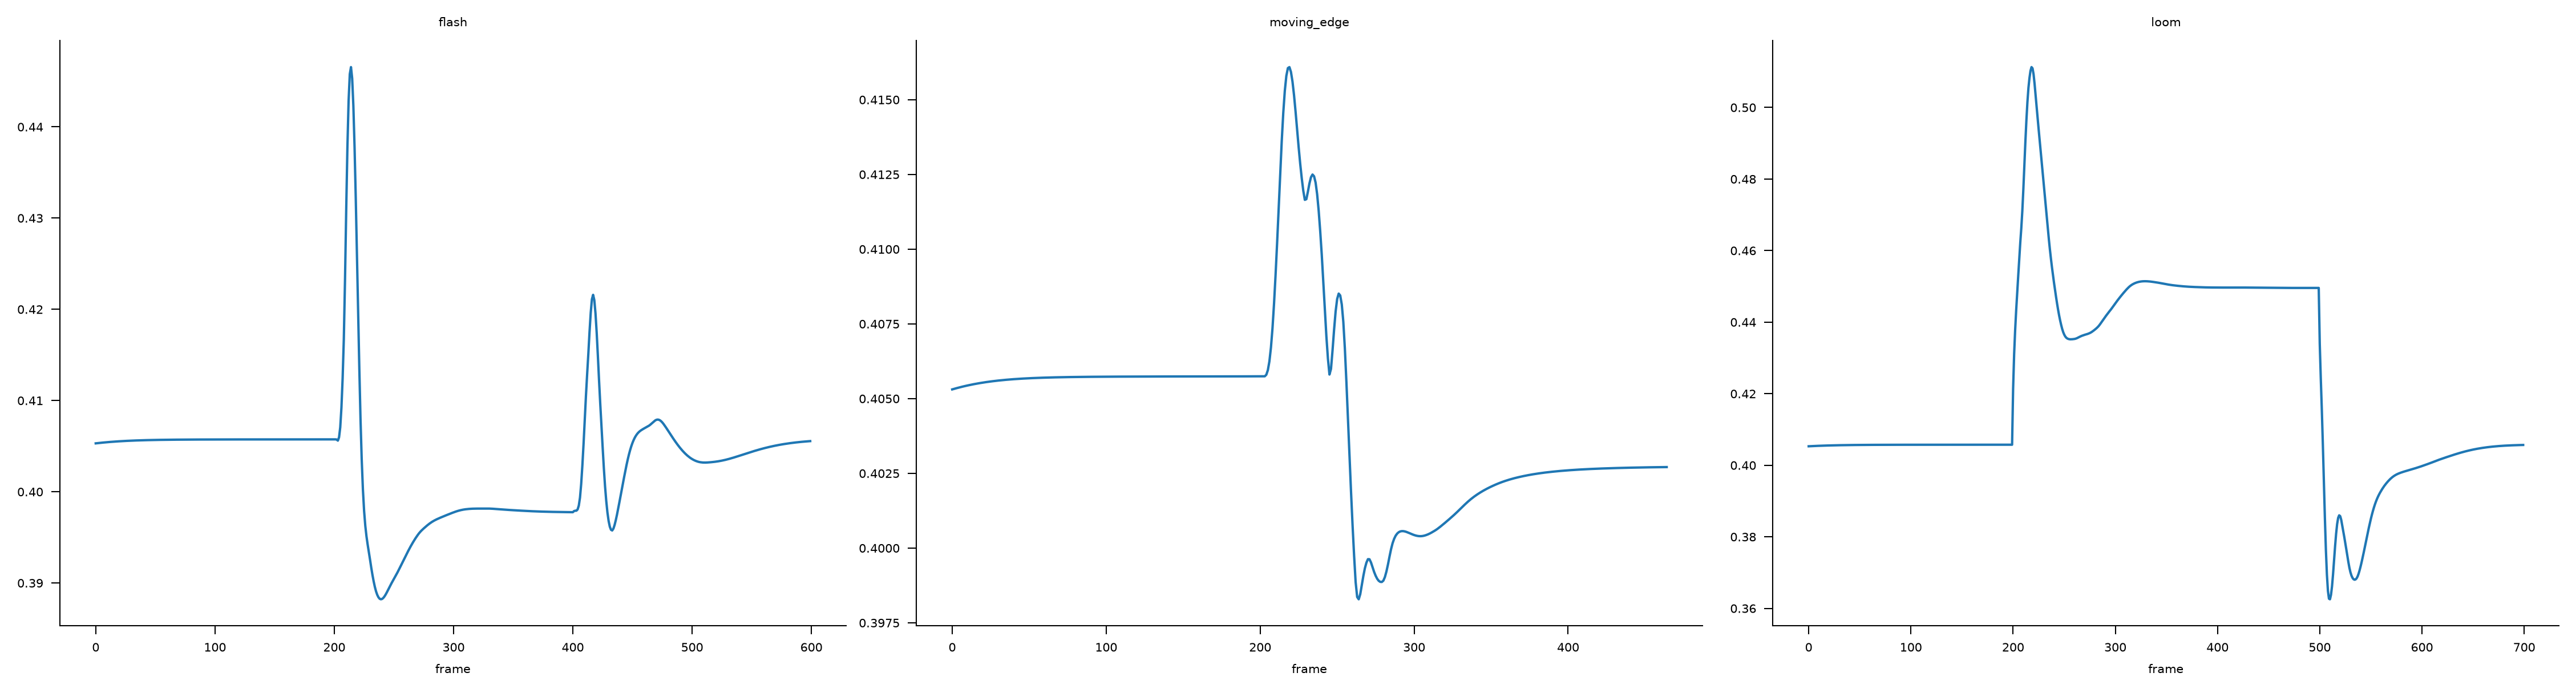

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, (name, resp) in zip(axes, responses.items()):
    vals = np.asarray(resp["responses"].values)
    trace = vals[0].mean(axis=(0, -1)) if vals.ndim == 4 else vals.mean(axis=1)
    ax.plot(trace, label="mean central-cell response")
    ax.set_title(name)
    ax.set_xlabel("frame")
fig.tight_layout()
plt.show()

In [5]:
# Per-stimulus sanity metrics: finite? distinguishable across stimuli?
sanity = _summary_metrics({name: (np.asarray(r["responses"].values), {}) for name, r in responses.items()})
for name, m in sanity.items():
    if isinstance(m, dict) and "finite" in m:
        print(f"{name:12s} finite={m['finite']}  mean|r|={m['mean_abs_response']}  std={m['std_response']}")
print("pairwise trace MSE:", sanity.get("pairwise_trace_mse"))
print("signature norms:", sanity.get("signature_norms"))

flash        finite=True  mean|r|=0.676277  std=0.90111
moving_edge  finite=True  mean|r|=0.691495  std=0.91481
loom         finite=True  mean|r|=0.743148  std=1.034735
pairwise trace MSE: {'flash_vs_moving_edge_mse': 5.432e-05, 'flash_vs_loom_mse': 0.00139767, 'moving_edge_vs_loom_mse': 0.0014009}
signature norms: {'flash': 9.879304, 'moving_edge': 8.721498, 'loom': 11.198231}


## Circuit status

The loom-escape substrate is real flyvis activity at the optic lobe. The MaleCNS leg — LC4/LPLC2 → DNp01 loom-escape path — is pulled only after a `NEUPRINT_TOKEN` is placed in `.env`:

```
from hawking_fly.connectome import ConnectomeClient, query_loom_escape_circuit
client = ConnectomeClient()
data = query_loom_escape_circuit(client)   # NoTokenError until the token is set
```

Until then, Phase 0A stands on the validated pretrained visual component alone.

---

## Phase 0A validation report

The full Phase 0A milestone report (sanity metrics, LC4/LPLC2-correspondent
read-out table, honest limitation that the *bright-disk* synthetic loom is
**not** maximal at the optic lobe, and the in-repo layer attribution table)
lives at [`docs/phase_0a.md`](../docs/phase_0a.md).

Reproduce the stored-run validation (no re-inference):

```bash
python -m hawking_fly.sensory.validation \
  --run-dir experiments/loom_escape/20260916-223510 \
  --out experiments/loom_escape/phase_0a_validation
```
